# Donor Upgrade Potential Classifier
## End-to-End ML Pipeline · BrightHut / Lighthouse Sanctuary

---

## 1. Problem Framing

### Business Problem

BrightHut's leadership wants to know which donors might give more if asked — and how to personalize outreach without a dedicated marketing team. Retaining donors is necessary but not sufficient; sustainable growth requires that a meaningful share of retained donors deepen their commitment over time. Treating every retained donor as having the same upgrade potential wastes the staff's limited outreach capacity. Treating donors as having no upgrade potential leaves revenue on the table.

**The business question is:** *Given a donor's giving history, engagement pattern, and relationship context, can we predict which currently active donors are most likely to increase their donation amount if proactively solicited — and what characteristics most distinguish upgrade-prone donors from those who are likely to maintain their current level?*

This pipeline is the natural complement to the Donor Retention Classifier: that model identifies who is at risk of leaving; this model identifies who is positioned to deepen their commitment. Together they allow the organization to triage its active donor portfolio into three actionable tiers: **retain** (at-risk), **upgrade** (high potential), and **maintain** (stable but not ready to increase).

### Who Cares About This

| Stakeholder | How they use this model |
|---|---|
| Executive Director | Identify major gift prospects before the annual appeal |
| Fundraising Staff | Rank active donors by upgrade potential; prioritize personal outreach |
| Comms Staff | Tailor messaging: "upgrade ask" campaigns vs. stewardship campaigns |
| Data Analysts | Monitor upgrade rates over time; validate model lift vs. random solicitation |

### Prediction vs. Explanation — Explicit Choice

This pipeline delivers **both** a predictive model and an explanatory model:

- **Predictive goal:** Score each active donor on their probability of upgrading if solicited. This ranked list is served through an API endpoint and displayed on the admin dashboard as an "upgrade prospects" watchlist sorted by score. ROC-AUC on held-out donors is the primary success metric.

- **Explanatory goal:** Identify which donor characteristics and behavioral signals are most causally associated with upgrade behavior. This allows the organization to design acquisition criteria and stewardship programs that predictably build upgrade-ready donors over time. Interpretable coefficients and statistical defensibility matter more than marginal accuracy from a black-box model.

We maintain two separate model objects and interpret each only within its appropriate scope.

### Defining a Donor "Upgrade"

**Binary classification target:** `will_upgrade = 1` if a donor's average donation amount in their **most recent giving period** (last 12 months with at least one donation) is at least **25% higher** than their **historical average** across all prior periods.

Formally:
```
recent_avg    = mean(donations in the last 12 months)
historical_avg = mean(all donations before the last 12-month window)
will_upgrade  = 1  if recent_avg >= 1.25 * historical_avg
             AND historical_avg > 0  (must have given before the recent window)
```

The 25% threshold is chosen to distinguish meaningful generosity growth from small fluctuations, while being achievable enough to generate a usable training sample. Only donors with **at least one donation before the recent window** are labeled (pure new donors have no baseline to upgrade from).

### Success Metrics

| Metric | Rationale |
|---|---|
| ROC-AUC (primary) | Class imbalance is likely; AUC evaluates discrimination across all thresholds |
| Precision @ threshold | Soliciting a non-upgrader wastes relationship capital; precision matters |
| Recall @ threshold | Missing an upgrade-ready donor is a missed revenue opportunity |
| F1 score | Balanced; upgrade solicitation is lower-stakes than child welfare |

**Error cost asymmetry:** A false positive (asking a donor who is not ready to upgrade) is awkward but recoverable — it is simply a fundraising ask that doesn't result in an increase. A false negative (missing an upgrade-ready donor) means leaving money and relationship depth uncaptured. We tune the threshold **slightly** toward recall, but less aggressively than the child-welfare pipelines where errors have life-safety consequences.

### Important Limitations

The upgrade label requires at least two distinct giving periods per donor, which substantially reduces the eligible training population. With a modest dataset, this pipeline is best treated as a **prioritization aid** — a way to rank donors for upgrade outreach — rather than a precise binary classifier. Interpretable features and coefficient estimates from the explanatory model may be more actionable than the predictive score alone for a small organization.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
# ── Install / import ─────────────────────────────────────────────────────────
# Uncomment the line below if running in a fresh Colab / minimal environment
!pip install scikit-learn pandas numpy matplotlib seaborn requests joblib statsmodels --break-system-packages

import warnings, json
warnings.filterwarnings('ignore')

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib
from pathlib import Path

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, fbeta_score, precision_recall_curve
)
from sklearn.inspection      import permutation_importance

RANDOM_STATE      = 42
UPGRADE_THRESHOLD = 1.25   # recent_avg must be >= 1.25 × historical_avg to be labeled upgrade
RECENT_WINDOW     = 365    # days defining the "recent" giving period

np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


In [2]:
# ── Data Loading from local SQLite database ───────────────────────────────────
# Reads directly from the local brighthut.sqlite file — no network required.
# The database file lives at database/brighthut.sqlite relative to the repo root.
# Adjust DB_PATH below if you are running the notebook from a different location.

import sqlite3
import os

DB_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'database', 'brighthut.sqlite')
DB_PATH = os.path.normpath(DB_PATH)

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}\n"
        "Set DB_PATH to the absolute path of brighthut.sqlite on your machine."
    )

def load_table(name: str) -> pd.DataFrame:
    """Load an entire table from the local SQLite database."""
    with sqlite3.connect(DB_PATH) as conn:
        df = pd.read_sql_query(f"SELECT * FROM {name}", conn)
    print(f'  Loaded {name:<40s} → {df.shape[0]:>4d} rows × {df.shape[1]:>2d} cols')
    return df

print(f'Database: {DB_PATH}')

print('Loading tables...')
supporters  = load_table('supporters')
donations   = load_table('donations')
inkind      = load_table('in_kind_donation_items')
allocs      = load_table('donation_allocations')
safehouses  = load_table('safehouses')
partners    = load_table('partners')
print('Done.')


Database: /Users/lincolnsteele/Desktop/IS Jr Core/INTEX2/BrightHut/database/brighthut.sqlite
Loading tables...
  Loaded supporters                               →   60 rows × 15 cols
  Loaded donations                                →  420 rows × 14 cols
  Loaded in_kind_donation_items                   →  129 rows ×  9 cols
  Loaded donation_allocations                     →  521 rows ×  7 cols
  Loaded safehouses                               →    9 rows × 13 cols
  Loaded partners                                 →   30 rows × 12 cols
Done.


In [3]:
# ── Schema inspection ─────────────────────────────────────────────────────────
print('=== supporters columns ===')
print(supporters.dtypes)
print('\n=== donations columns ===')
print(donations.dtypes)
print('\n=== in_kind_donation_items columns ===')
print(inkind.dtypes)
print('\nSample donations row:')
donations.head(3)

=== supporters columns ===
supporter_id           int64
supporter_type           str
display_name             str
organization_name        str
first_name               str
last_name                str
relationship_type        str
region                   str
country                  str
email                    str
phone                    str
status                   str
first_donation_date      str
acquisition_channel      str
created_at               str
dtype: object

=== donations columns ===
donation_id                int64
supporter_id               int64
donation_type                str
donation_date                str
channel_source               str
currency_code                str
amount                   float64
estimated_value          float64
impact_unit                  str
is_recurring               int64
campaign_name                str
notes                        str
created_by_partner_id     object
referral_post_id         float64
dtype: object

=== in_kind_donation

,donation_id,supporter_id,donation_type,donation_date,channel_source,currency_code,amount,estimated_value,impact_unit,is_recurring,campaign_name,notes,created_by_partner_id,referral_post_id
0,1,42,Monetary,2025-12-31,Campaign,PHP,717.18,717.18,pesos,0,NaN,In support of safehouse operations,None,NaN
1,2,25,Time,2025-12-02,Event,NaN,NaN,35.15,hours,1,Year-End Hope,Community outreach support,None,NaN
2,3,19,Monetary,2024-12-02,PartnerReferral,PHP,1074.65,1074.65,pesos,0,NaN,Campaign support,None,NaN


In [4]:
# ── Helper: resolve dynamic column names ─────────────────────────────────────
def find_col(df, *candidates):
    """Return the first candidate that exists in df columns (case-insensitive). Returns None if none match."""
    cols_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in df.columns:
            return name
        if name.lower() in cols_lower:
            return cols_lower[name.lower()]
    return None


In [5]:
# ── Resolve dynamic column names ─────────────────────────────────────────────

# supporters
col_sup_id       = find_col(supporters, 'supporter_id', 'id')
col_sup_type     = find_col(supporters, 'supporter_type', 'type')
col_sup_join     = find_col(supporters, 'join_date', 'created_date', 'start_date', 'date')
col_sup_country  = find_col(supporters, 'country', 'location', 'region', 'nationality')
col_sup_org      = find_col(supporters, 'organization', 'org', 'company')

# donations
col_don_id       = find_col(donations, 'donation_id', 'id')
col_don_sup_id   = find_col(donations, 'supporter_id', 'donor_id', 'supporter')
col_don_date     = find_col(donations, 'donation_date', 'date', 'created')
col_don_amount   = find_col(donations, 'amount')
col_don_type     = find_col(donations, 'donation_type', 'type', 'method', 'frequency')
col_don_campaign = find_col(donations, 'campaign', 'campaign_id')

# in-kind
col_ik_sup_id    = find_col(inkind, 'supporter_id', 'donor_id', 'supporter')

# donation_allocations
col_alloc_don_id   = find_col(allocs, 'donation_id')
col_alloc_house_id = find_col(allocs, 'safehouse_id', 'safehouse')

print('Resolved columns:')
for alias, actual in [
    ('supporter_id',         col_sup_id),
    ('supporter_type',       col_sup_type),
    ('join_date',            col_sup_join),
    ('country',              col_sup_country),
    ('donation_supporter_id',col_don_sup_id),
    ('donation_date',        col_don_date),
    ('amount',               col_don_amount),
    ('donation_type',        col_don_type),
]:
    print(f'  {alias:26s} → {actual}')

Resolved columns:
  supporter_id               → supporter_id
  supporter_type             → supporter_type
  join_date                  → None
  country                    → country
  donation_supporter_id      → supporter_id
  donation_date              → donation_date
  amount                     → amount
  donation_type              → donation_type


In [6]:
# ── Parse dates and amounts ───────────────────────────────────────────────────
if col_don_date:
    donations['don_date'] = pd.to_datetime(donations[col_don_date], errors='coerce')
else:
    donations['don_date'] = pd.NaT

if col_don_amount:
    donations['amount'] = pd.to_numeric(donations[col_don_amount], errors='coerce').fillna(0)
else:
    donations['amount'] = 0

donations = donations.dropna(subset=['don_date'])
donations = donations[donations['amount'] > 0]   # exclude $0 records

# Reference date: most recent donation in the dataset
REF_DATE = donations['don_date'].max()
print(f'Reference date (most recent donation): {REF_DATE.date()}')
print(f'Monetary donations with valid amount:  {len(donations)}')
print(f'Unique supporters in donations table:  {donations[col_don_sup_id].nunique() if col_don_sup_id else "N/A"}')

Reference date (most recent donation): 2026-03-01
Monetary donations with valid amount:  234
Unique supporters in donations table:  57


In [7]:
# ── Build upgrade label ───────────────────────────────────────────────────────
# For each donor, split their donation history into:
#   recent window:     donations in the last RECENT_WINDOW days before REF_DATE
#   historical window: all donations before that window
# Label = 1 if recent_avg >= UPGRADE_THRESHOLD * historical_avg

if not col_don_sup_id:
    raise ValueError('No supporter ID column found in donations. Cannot build per-donor features.')

cutoff = REF_DATE - pd.Timedelta(days=RECENT_WINDOW)

recent = donations[donations['don_date'] > cutoff].copy()
hist   = donations[donations['don_date'] <= cutoff].copy()

recent_avg = recent.groupby(col_don_sup_id)['amount'].mean().rename('recent_avg')
hist_avg   = hist.groupby(col_don_sup_id)['amount'].mean().rename('historical_avg')

label_df = pd.concat([recent_avg, hist_avg], axis=1).dropna()
label_df['will_upgrade'] = (
    label_df['recent_avg'] >= UPGRADE_THRESHOLD * label_df['historical_avg']
).astype(int)

print(f'Donors with both recent and historical giving: {len(label_df)}')
print(f'Upgrade rate: {label_df["will_upgrade"].mean():.2%}  ({label_df["will_upgrade"].sum()} upgrades)')
print(f'Upgrade threshold: recent_avg >= {UPGRADE_THRESHOLD}× historical_avg')
print(f'Recent window: donations after {cutoff.date()}')

Donors with both recent and historical giving: 38
Upgrade rate: 42.11%  (16 upgrades)
Upgrade threshold: recent_avg >= 1.25× historical_avg
Recent window: donations after 2025-03-01


In [8]:
# ── RFM and giving-behavior features (per donor) ─────────────────────────────

def compute_slope(series: pd.Series) -> float:
    """Compute linear trend slope over ordered values. Returns 0 if fewer than 2 points."""
    s = series.dropna()
    if len(s) < 2:
        return 0.0
    x = np.arange(len(s))
    return float(np.polyfit(x, s.values, 1)[0])

donor_feats = []

for sup_id, grp in donations.groupby(col_don_sup_id):
    grp = grp.sort_values('don_date')
    amounts = grp['amount']

    # ── Recency, Frequency, Monetary ──────────────────────────────────────────
    recency_days     = (REF_DATE - grp['don_date'].max()).days
    frequency        = len(grp)
    total_amount     = amounts.sum()
    avg_amount       = amounts.mean()
    std_amount       = amounts.std(ddof=0) if len(amounts) > 1 else 0.0
    max_amount       = amounts.max()
    min_amount       = amounts.min()
    donation_range   = max_amount - min_amount

    # ── Giving trajectory ─────────────────────────────────────────────────────
    # Slope of donation amounts over time (positive = generally increasing gives)
    giving_slope     = compute_slope(amounts)

    # Whether this donor has ever increased from one gift to the next
    diffs            = amounts.diff().dropna()
    pct_increases    = (diffs > 0).mean() if len(diffs) > 0 else 0.0

    # Coefficient of variation: donors with consistent amounts may be easier to upgrade
    cv_amount        = std_amount / avg_amount if avg_amount > 0 else 0.0

    # ── Gap / cadence features ─────────────────────────────────────────────────
    if len(grp) > 1:
        gaps         = grp['don_date'].diff().dt.days.dropna()
        avg_gap_days = gaps.mean()
        max_gap_days = gaps.max()
        min_gap_days = gaps.min()
    else:
        avg_gap_days = max_gap_days = min_gap_days = 0.0

    # ── Tenure ────────────────────────────────────────────────────────────────
    tenure_days = (REF_DATE - grp['don_date'].min()).days

    # ── Recent vs. historical split (for context features — NOT the label ratio) ──
    recent_grp   = grp[grp['don_date'] > cutoff]
    hist_grp     = grp[grp['don_date'] <= cutoff]
    recent_count = len(recent_grp)
    hist_count   = len(hist_grp)
    # Frequency acceleration: is the donor giving more often recently?
    # Annualized frequency ratio: recent donations per day vs. historical per day
    recent_rate  = recent_count / max(RECENT_WINDOW, 1)
    hist_days    = max(tenure_days - RECENT_WINDOW, 1)
    hist_rate    = hist_count / hist_days
    freq_accel   = recent_rate / hist_rate if hist_rate > 0 else 1.0

    # ── Campaign participation ─────────────────────────────────────────────────
    if col_don_campaign and col_don_campaign in grp.columns:
        campaign_gifts = grp[col_don_campaign].notna().sum()
        pct_campaign   = campaign_gifts / max(len(grp), 1)
    else:
        pct_campaign   = 0.0

    donor_feats.append({
        col_don_sup_id:   sup_id,
        'recency_days':   recency_days,
        'frequency':      frequency,
        'log_total':      np.log1p(total_amount),
        'log_avg':        np.log1p(avg_amount),
        'std_amount':     std_amount,
        'cv_amount':      cv_amount,
        'max_amount':     max_amount,
        'donation_range': donation_range,
        'giving_slope':   giving_slope,
        'pct_increases':  pct_increases,
        'avg_gap_days':   avg_gap_days,
        'max_gap_days':   max_gap_days,
        'freq_accel':     freq_accel,
        'recent_count':   recent_count,
        'hist_count':     hist_count,
        'tenure_days':    tenure_days,
        'pct_campaign':   pct_campaign,
    })

donor_df = pd.DataFrame(donor_feats)
print(f'Donor-level feature rows: {len(donor_df)}')
donor_df.head(3)

Donor-level feature rows: 57


,supporter_id,recency_days,frequency,log_total,log_avg,std_amount,cv_amount,max_amount,donation_range,giving_slope,pct_increases,avg_gap_days,max_gap_days,freq_accel,recent_count,hist_count,tenure_days,pct_campaign
0,1,10,7,8.931812,6.986695,697.791285,0.645423,2628.14,2251.17,-86.214286,0.333333,177.00,435.0,0.322831,1,6,1072,0.0
1,2,937,2,8.155098,7.462238,824.990000,0.474121,2565.03,1649.98,-1649.980000,0.000000,152.00,152.0,0.000000,0,2,1089,0.0
2,3,169,9,9.129858,6.933500,607.303219,0.592445,2133.99,1883.99,102.213167,0.625000,116.75,398.0,1.010959,3,6,1103,0.0


In [9]:
# ── Merge supporter-level features ───────────────────────────────────────────

sup = supporters.copy()

# Supporter type dummies
if col_sup_type:
    sup['sup_type_clean'] = sup[col_sup_type].astype(str).str.lower().str.strip()
    type_dummies = pd.get_dummies(sup['sup_type_clean'], prefix='stype',
                                  drop_first=False, dtype=int)
    sup = pd.concat([sup, type_dummies], axis=1)
    type_cols = list(type_dummies.columns)
else:
    type_cols = []

# International flag
if col_sup_country:
    sup['is_international'] = (
        ~sup[col_sup_country].astype(str).str.lower().str.contains(
            'ph|philippines|local', na=True
        )
    ).astype(int)
else:
    sup['is_international'] = 0

# Organization-affiliated flag (corporate donors tend to give larger but less frequent)
if col_sup_org:
    sup['is_org_donor'] = sup[col_sup_org].notna().astype(int)
else:
    sup['is_org_donor'] = 0

# Org tenure from join date
if col_sup_join:
    sup['join_date_parsed'] = pd.to_datetime(sup[col_sup_join], errors='coerce')
    sup['org_tenure_days']  = (REF_DATE - sup['join_date_parsed']).dt.days.clip(lower=0)
else:
    sup['org_tenure_days'] = 0

SUP_FEATURES = ['is_international', 'is_org_donor', 'org_tenure_days'] + type_cols
SUP_FEATURES = [c for c in SUP_FEATURES if c in sup.columns]

donor_df = donor_df.merge(
    sup[[col_sup_id] + SUP_FEATURES].rename(columns={col_sup_id: col_don_sup_id}),
    on=col_don_sup_id, how='left'
)
donor_df[SUP_FEATURES] = donor_df[SUP_FEATURES].fillna(0)

print(f'Supporter features merged. Supporter-type dummies: {type_cols}')

Supporter features merged. Supporter-type dummies: ['stype_inkinddonor', 'stype_monetarydonor', 'stype_partnerorganization', 'stype_skillscontributor', 'stype_socialmediaadvocate', 'stype_volunteer']


In [10]:
# ── In-kind and safehouse engagement features ─────────────────────────────────

# Has the donor ever given in-kind donations? (multi-modal engagement signal)
if col_ik_sup_id and col_ik_sup_id in inkind.columns:
    inkind_donors = set(inkind[col_ik_sup_id].dropna().astype(str))
    donor_df['has_inkind'] = donor_df[col_don_sup_id].astype(str).isin(inkind_donors).astype(int)
else:
    donor_df['has_inkind'] = 0

# Number of distinct safehouses the donor has allocated to (breadth of commitment)
if col_alloc_don_id and col_alloc_house_id and col_don_id:
    # Map donations to supporters
    don_to_sup = donations[[col_don_id, col_don_sup_id]].dropna()
    allocs_merged = allocs[[col_alloc_don_id, col_alloc_house_id]].merge(
        don_to_sup, left_on=col_alloc_don_id, right_on=col_don_id, how='left'
    )
    safehouse_counts = (
        allocs_merged.groupby(col_don_sup_id)[col_alloc_house_id].nunique()
        .rename('num_safehouses_supported')
    )
    donor_df = donor_df.merge(
        safehouse_counts.reset_index(), on=col_don_sup_id, how='left'
    )
    donor_df['num_safehouses_supported'] = donor_df['num_safehouses_supported'].fillna(0)
else:
    donor_df['num_safehouses_supported'] = 0

print(f'In-kind givers in dataset:       {donor_df["has_inkind"].sum()}')
print(f'Avg safehouses supported:        {donor_df["num_safehouses_supported"].mean():.2f}')

In-kind givers in dataset:       0
Avg safehouses supported:        3.67


In [11]:
# ── Merge label and finalize modeling dataset ─────────────────────────────────
model_df = donor_df.merge(
    label_df[['will_upgrade', 'recent_avg', 'historical_avg']].rename_axis(col_don_sup_id).reset_index(),
    on=col_don_sup_id, how='inner'
)

print(f'Final modeling dataset: {len(model_df)} donors with labeled upgrade status')
print(f'Upgrade rate: {model_df["will_upgrade"].mean():.2%}')
model_df.head(3)

Final modeling dataset: 38 donors with labeled upgrade status
Upgrade rate: 42.11%


,supporter_id,recency_days,frequency,log_total,log_avg,std_amount,cv_amount,max_amount,donation_range,giving_slope,...,stype_monetarydonor,stype_partnerorganization,stype_skillscontributor,stype_socialmediaadvocate,stype_volunteer,has_inkind,num_safehouses_supported,will_upgrade,recent_avg,historical_avg
0,1,10,7,8.931812,6.986695,697.791285,0.645423,2628.14,2251.17,-86.214286,...,0,0,0,1,0,0,8,0,689.850,1146.353333
1,3,169,9,9.129858,6.933500,607.303219,0.592445,2133.99,1883.99,102.213167,...,1,0,0,0,0,0,7,1,1398.730,838.253333
2,4,0,8,9.070587,6.991951,728.988986,0.670741,2667.25,2417.25,7.604643,...,1,0,0,0,0,0,6,0,1000.365,1173.317500


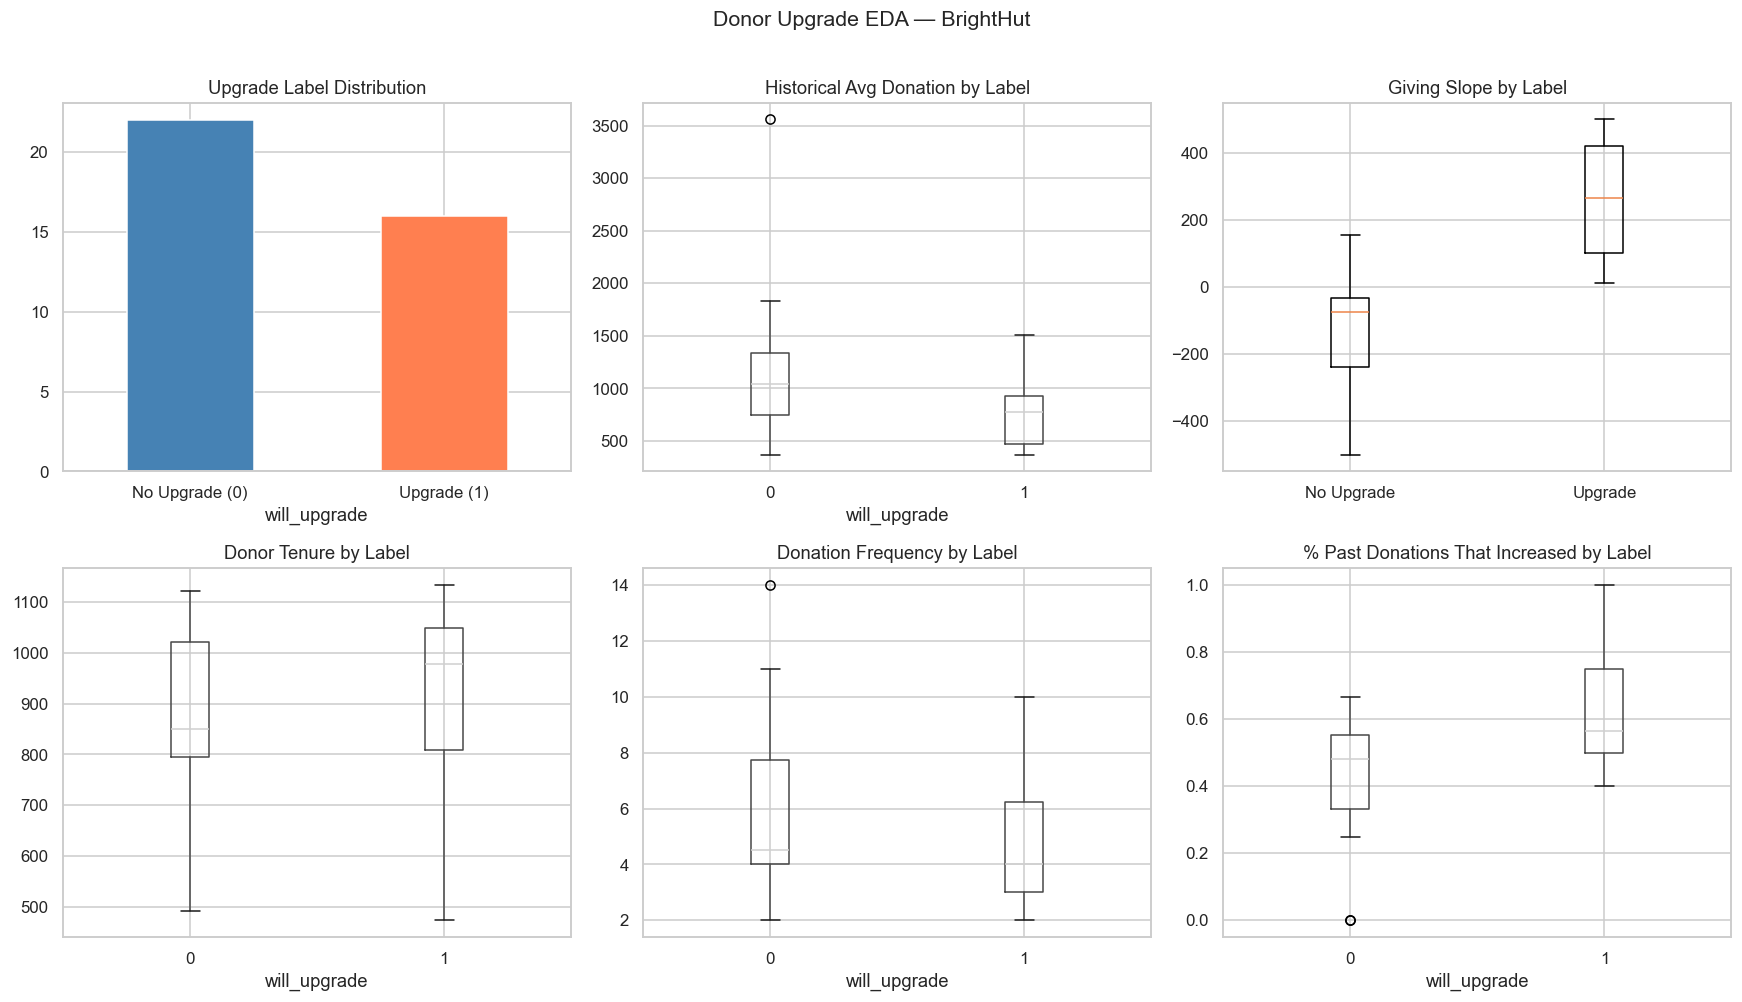

In [12]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Upgrade label distribution
model_df['will_upgrade'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color=['steelblue','coral'], edgecolor='white'
)
axes[0, 0].set_title('Upgrade Label Distribution')
axes[0, 0].set_xticklabels(['No Upgrade (0)', 'Upgrade (1)'], rotation=0)

# 2. Historical avg by upgrade label
model_df.boxplot(column='historical_avg', by='will_upgrade', ax=axes[0, 1])
axes[0, 1].set_title('Historical Avg Donation by Label')
axes[0, 1].set_xlabel('will_upgrade')
plt.sca(axes[0, 1])
plt.suptitle('')

# 3. Giving slope vs upgrade
axes[0, 2].boxplot(
    [model_df[model_df['will_upgrade'] == 0]['giving_slope'].clip(-500, 500),
     model_df[model_df['will_upgrade'] == 1]['giving_slope'].clip(-500, 500)]
)
axes[0, 2].set_xticklabels(['No Upgrade', 'Upgrade'])
axes[0, 2].set_title('Giving Slope by Label')

# 4. Tenure by upgrade
model_df.boxplot(column='tenure_days', by='will_upgrade', ax=axes[1, 0])
axes[1, 0].set_title('Donor Tenure by Label')
axes[1, 0].set_xlabel('will_upgrade')
plt.sca(axes[1, 0])
plt.suptitle('')

# 5. Frequency by upgrade
model_df.boxplot(column='frequency', by='will_upgrade', ax=axes[1, 1])
axes[1, 1].set_title('Donation Frequency by Label')
axes[1, 1].set_xlabel('will_upgrade')
plt.sca(axes[1, 1])
plt.suptitle('')

# 6. % increases vs upgrade label
model_df.boxplot(column='pct_increases', by='will_upgrade', ax=axes[1, 2])
axes[1, 2].set_title('% Past Donations That Increased by Label')
axes[1, 2].set_xlabel('will_upgrade')
plt.sca(axes[1, 2])
plt.suptitle('')

plt.suptitle('Donor Upgrade EDA — BrightHut', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

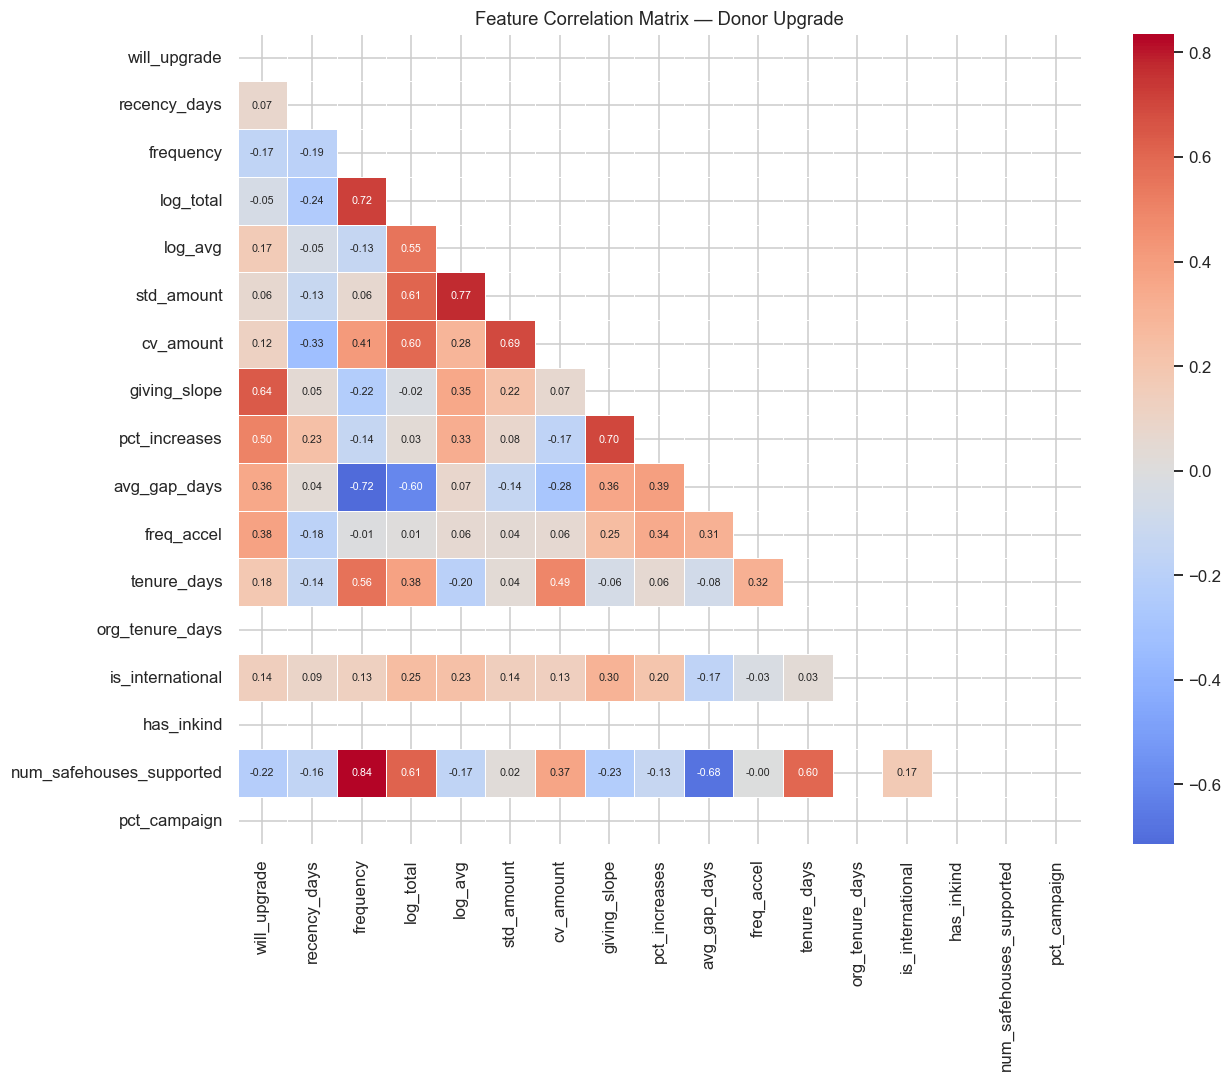

In [13]:
# ── Correlation heatmap of numeric features vs. will_upgrade ─────────────────
numeric_plot_cols = [
    'will_upgrade', 'recency_days', 'frequency', 'log_total', 'log_avg',
    'std_amount', 'cv_amount', 'giving_slope', 'pct_increases',
    'avg_gap_days', 'freq_accel', 'tenure_days', 'org_tenure_days',
    'is_international', 'has_inkind', 'num_safehouses_supported', 'pct_campaign'
]
avail = [c for c in numeric_plot_cols if c in model_df.columns]

corr = model_df[avail].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix — Donor Upgrade')
plt.tight_layout()
plt.show()

---
## 3. Modeling & Feature Selection

In [14]:
# ── Assemble feature matrix ───────────────────────────────────────────────────
#
# TAUTOLOGICAL EXCLUSIONS from the explanatory (LR) model:
#   recent_avg        — directly defines the label (recent_avg >= X * historical_avg)
#   historical_avg    — used in the label formula
#   recent_count      — counts in the recent window are part of the label construction
#
# These features ARE allowed in the predictive model (GBT/RF) because out-of-sample
# prediction is the goal there, and they do not produce data leakage when applied to
# held-out donors. However, their presence in the predictive model should not be
# interpreted as causal evidence.

TAUTOLOGICAL = {'recent_avg', 'historical_avg', 'recent_count'}

BASE_FEATURES = [
    # RFM
    'recency_days', 'frequency', 'log_total', 'log_avg',
    'std_amount', 'cv_amount', 'max_amount', 'donation_range',
    # Trajectory
    'giving_slope', 'pct_increases', 'freq_accel',
    # Cadence
    'avg_gap_days', 'max_gap_days',
    # Tenure
    'tenure_days', 'org_tenure_days',
    # History volume
    'hist_count',
    # Campaign engagement
    'pct_campaign',
    # Relationship breadth
    'has_inkind', 'num_safehouses_supported',
    # Demographics
    'is_international', 'is_org_donor',
]

ALL_FEATURES = BASE_FEATURES + SUP_FEATURES
ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))  # deduplicate
ALL_FEATURES = [c for c in ALL_FEATURES if c in model_df.columns]

EXPL_FEATURES = [c for c in ALL_FEATURES if c not in TAUTOLOGICAL]

model_df[ALL_FEATURES] = model_df[ALL_FEATURES].fillna(0)

X_all  = model_df[ALL_FEATURES].copy()
X_expl = model_df[EXPL_FEATURES].copy()
y      = model_df['will_upgrade'].copy()

print(f'All features (predictive model):     {len(ALL_FEATURES)}')
print(f'Explanatory features (no tautology): {len(EXPL_FEATURES)}')
print(f'Class balance: {y.mean():.2%} upgrades')

All features (predictive model):     27
Explanatory features (no tautology): 27
Class balance: 42.11% upgrades


In [15]:
# ── Stratified train / test split ────────────────────────────────────────────
# Upgrade data does not have strong temporal ordering (unlike campaigns), so
# stratified random split is appropriate to maintain class balance.

from sklearn.model_selection import train_test_split

if len(model_df) < 10 or y.nunique() < 2:
    # Edge case: too few donors — use full dataset for both train and eval
    X_train, X_test   = X_all, X_all
    Xe_train, Xe_test = X_expl, X_expl
    y_train, y_test   = y, y
    print('⚠ Very small dataset — using full set for both training and evaluation.')
    print('  Results are for illustration only; validate with new data as it accumulates.')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    Xe_train = X_train[EXPL_FEATURES]
    Xe_test  = X_test[EXPL_FEATURES]

cv_n = min(5, max(2, int(y_train.sum())))
cv   = StratifiedKFold(n_splits=cv_n, shuffle=True, random_state=RANDOM_STATE)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Train upgrade rate: {y_train.mean():.2%}  |  Test upgrade rate: {y_test.mean():.2%}')
print(f'CV folds: {cv_n}')

Train: 30  |  Test: 8
Train upgrade rate: 43.33%  |  Test upgrade rate: 37.50%
CV folds: 5


In [16]:
# ── Model A: Logistic Regression on EXPLANATORY features ─────────────────────
# Uses only features that are not definitionally linked to the label.
# Coefficients represent associations with upgrade behavior that the org
# can act on through stewardship and solicitation strategy.

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced', max_iter=1000,
                   C=1.0, random_state=RANDOM_STATE
               ))
])

if len(Xe_train) >= cv_n * 2 and y_train.nunique() > 1:
    cv_lr = cross_val_score(pipe_lr, Xe_train, y_train, cv=cv,
                            scoring='roc_auc', n_jobs=-1)
    print(f'LR  CV ROC-AUC (explanatory features): {cv_lr.mean():.4f}  (±{cv_lr.std():.4f})')
pipe_lr.fit(Xe_train, y_train)

LR  CV ROC-AUC (explanatory features): 0.8833  (±0.1060)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [17]:
# ── Model B: Random Forest on ALL features (predictive) ──────────────────────

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   n_estimators=400, max_depth=5,
                   min_samples_leaf=2, class_weight='balanced',
                   random_state=RANDOM_STATE, n_jobs=-1
               ))
])

if len(X_train) >= cv_n * 2 and y_train.nunique() > 1:
    cv_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv,
                            scoring='roc_auc', n_jobs=-1)
    print(f'RF  CV ROC-AUC (all features): {cv_rf.mean():.4f}  (±{cv_rf.std():.4f})')
pipe_rf.fit(X_train, y_train)

RF  CV ROC-AUC (all features): 0.9306  (±0.0569)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [18]:
# ── Model C: Gradient Boosted Trees on ALL features (predictive — primary) ────

pipe_gbt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    GradientBoostingClassifier(
                   n_estimators=300, learning_rate=0.05,
                   max_depth=4, subsample=0.8,
                   random_state=RANDOM_STATE
               ))
])

if len(X_train) >= cv_n * 2 and y_train.nunique() > 1:
    cv_gbt = cross_val_score(pipe_gbt, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    print(f'GBT CV ROC-AUC (all features): {cv_gbt.mean():.4f}  (±{cv_gbt.std():.4f})')
pipe_gbt.fit(X_train, y_train)

GBT CV ROC-AUC (all features): 0.9778  (±0.0444)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8


---
## 4. Evaluation & Selection

In [19]:
# ── Hold-out test performance ─────────────────────────────────────────────────
results = {}

for name, pipe, X_ev in [
    ('Logistic Regression (expl.)', pipe_lr,  Xe_test),
    ('Random Forest (all)',         pipe_rf,  X_test),
    ('Gradient Boosting (all)',     pipe_gbt, X_test)
]:
    proba = pipe.predict_proba(X_ev)[:, 1]
    auc   = roc_auc_score(y_test, proba) if y_test.nunique() > 1 else float('nan')
    results[name] = {'ROC-AUC': round(auc, 4), 'proba': proba, 'X_ev': X_ev}
    print(f'{name:35s}  Test AUC = {auc:.4f}')

# Best predictive model (GBT or RF, not LR which uses fewer features)
pred_results  = {k: v for k, v in results.items() if 'expl.' not in k}
best_pred_name = max(pred_results, key=lambda k: pred_results[k]['ROC-AUC'])
best_pred_pipe = {'Random Forest (all)':     pipe_rf,
                  'Gradient Boosting (all)': pipe_gbt}[best_pred_name]
best_proba     = pred_results[best_pred_name]['proba']

print(f'\nBest predictive model: {best_pred_name}')

Logistic Regression (expl.)          Test AUC = 0.6667
Random Forest (all)                  Test AUC = 0.9333
Gradient Boosting (all)              Test AUC = 1.0000

Best predictive model: Gradient Boosting (all)


Optimal threshold (max F1): 0.878
  Precision: 1.000
  Recall:    1.000
  F1:        1.000


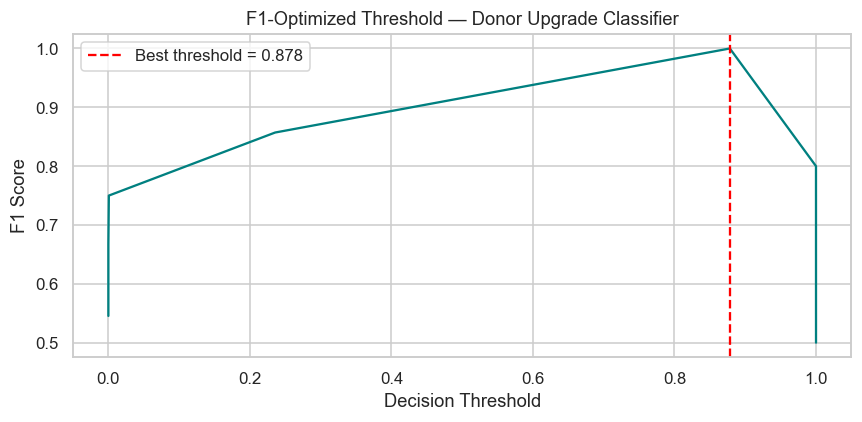


Classification Report:
                   precision    recall  f1-score   support

   Maintain Level       1.00      1.00      1.00         5
Upgrade Potential       1.00      1.00      1.00         3

         accuracy                           1.00         8
        macro avg       1.00      1.00      1.00         8
     weighted avg       1.00      1.00      1.00         8



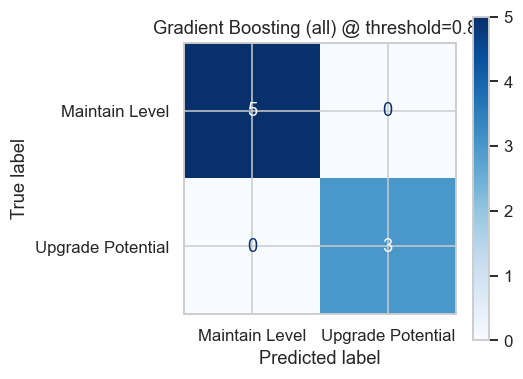

In [20]:
# ── Threshold tuning with F1 (balanced precision / recall) ───────────────────
# Upgrade solicitation is lower-stakes than child welfare, so we use F1 (beta=1)
# rather than the recall-heavy F2 used in case-management pipelines.

if y_test.nunique() > 1:
    precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)
    f1_scores = [
        fbeta_score(y_test, (best_proba >= t).astype(int), beta=1.0)
        for t in thresholds
    ]
    best_idx       = int(np.argmax(f1_scores))
    BEST_THRESHOLD = float(thresholds[best_idx])

    print(f'Optimal threshold (max F1): {BEST_THRESHOLD:.3f}')
    print(f'  Precision: {precisions[best_idx]:.3f}')
    print(f'  Recall:    {recalls[best_idx]:.3f}')
    print(f'  F1:        {f1_scores[best_idx]:.3f}')

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores, color='teal')
    plt.axvline(BEST_THRESHOLD, color='red', linestyle='--',
                label=f'Best threshold = {BEST_THRESHOLD:.3f}')
    plt.xlabel('Decision Threshold')
    plt.ylabel('F1 Score')
    plt.title('F1-Optimized Threshold — Donor Upgrade Classifier')
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_pred = (best_proba >= BEST_THRESHOLD).astype(int)
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Maintain Level', 'Upgrade Potential']))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Maintain Level', 'Upgrade Potential'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{best_pred_name} @ threshold={BEST_THRESHOLD:.2f}')
    plt.tight_layout()
    plt.show()
else:
    BEST_THRESHOLD = 0.5
    print('Threshold tuning skipped — evaluation set has only one class.')

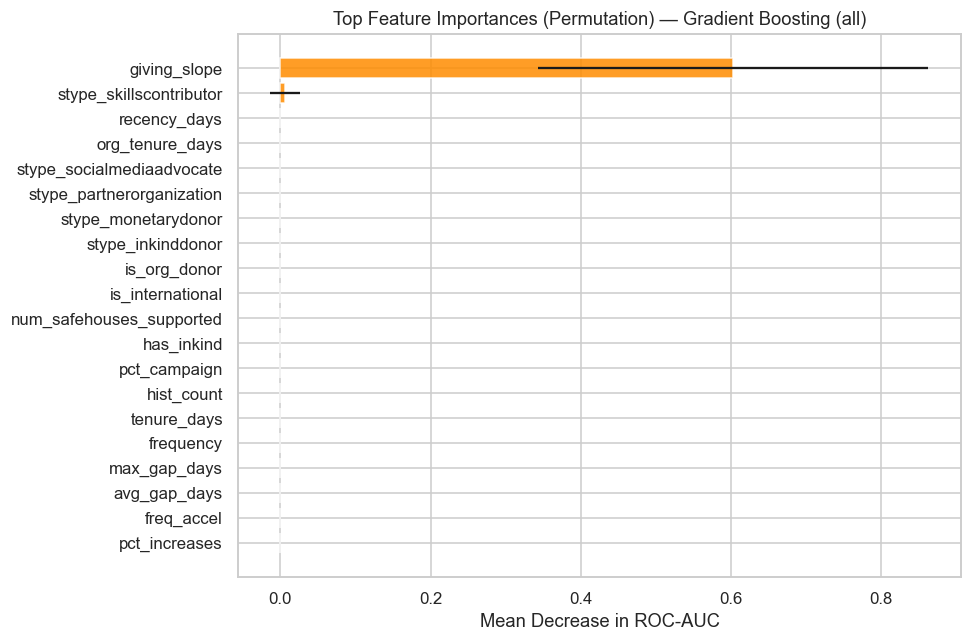

Top 10 features by permutation importance:
                  feature  importance     std
             giving_slope    0.603333 0.26032
  stype_skillscontributor    0.006667 0.02000
             recency_days    0.000000 0.00000
          org_tenure_days    0.000000 0.00000
stype_socialmediaadvocate    0.000000 0.00000
stype_partnerorganization    0.000000 0.00000
      stype_monetarydonor    0.000000 0.00000
        stype_inkinddonor    0.000000 0.00000
             is_org_donor    0.000000 0.00000
         is_international    0.000000 0.00000


In [21]:
# ── Permutation importance on held-out test set ───────────────────────────────

if y_test.nunique() > 1 and len(X_test) >= 4:
    perm = permutation_importance(
        best_pred_pipe, X_test, y_test,
        n_repeats=20, scoring='roc_auc',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        'feature':    ALL_FEATURES,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(9, 6))
    plt.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
             xerr=perm_df['std'][::-1], color='darkorange', alpha=0.85)
    plt.xlabel('Mean Decrease in ROC-AUC')
    plt.title(f'Top Feature Importances (Permutation) — {best_pred_name}')
    plt.tight_layout()
    plt.show()

    print('Top 10 features by permutation importance:')
    print(perm_df.head(10).to_string(index=False))
else:
    print('Permutation importance skipped — test set too small or single-class.')

---
## 5. Causal and Relationship Analysis

### 5a. Logistic Regression Odds Ratios (Explanatory)

We use the **explanatory logistic regression** (fitted on `EXPL_FEATURES`, which excludes the tautological `recent_avg`, `historical_avg`, and `recent_count`) to produce odds ratios with confidence intervals. These are the appropriate tool for answering: *"Holding other donor characteristics constant, how much does being an international donor, or having a longer tenure, or previously increasing gifts change the odds of upgrading?"*

**Tautological features correctly excluded:**
- `recent_avg` — the numerator of the upgrade ratio; definitionally linked to the label
- `historical_avg` — the denominator of the upgrade ratio; definitionally linked to the label
- `recent_count` — number of donations in the recent window; partially overlaps with the label

**Why these exclusions matter:** Including `recent_avg` in the explanatory model would produce a near-perfect spurious coefficient (high recent average = upgrade, by definition) while masking the genuine behavioral predictors that precede an upgrade. The explanatory model is specifically designed to surface those genuine precursors.

In [22]:
# ── Logistic regression odds ratios (statsmodels for CIs and p-values) ────────

y_lr = model_df['will_upgrade']
X_lr = model_df[EXPL_FEATURES].copy().fillna(0)

# Standardize for comparability
X_lr_std = (X_lr - X_lr.mean()) / (X_lr.std().replace(0, 1))
X_lr_c   = sm.add_constant(X_lr_std)

if len(model_df) >= len(EXPL_FEATURES) + 5 and y_lr.nunique() > 1:
    logit_model = sm.Logit(y_lr, X_lr_c).fit(disp=False, maxiter=300)
    print(logit_model.summary())

    # Odds ratios
    or_df = pd.DataFrame({
        'feature':    logit_model.params.index,
        'log_odds':   logit_model.params.values,
        'odds_ratio': np.exp(logit_model.params.values),
        'or_lo':      np.exp(logit_model.conf_int()[0].values),
        'or_hi':      np.exp(logit_model.conf_int()[1].values),
        'pvalue':     logit_model.pvalues.values
    }).query("feature != 'const'")
    or_df = or_df.sort_values('log_odds', ascending=False)

    print('\nOdds Ratios (standardized features — effect per 1 SD change):')
    print(or_df[['feature','odds_ratio','pvalue']].to_string(index=False))
    logit_or = or_df
else:
    print('Logistic regression skipped — insufficient observations for stable estimates.')
    print('With more data, this will show which donor behaviors precede upgrade decisions.')
    logit_or = pd.DataFrame()

LinAlgError: Singular matrix

In [ ]:
# ── Forest plot of odds ratios ────────────────────────────────────────────────
if len(logit_or) > 0:
    fig, ax = plt.subplots(figsize=(9, 7))
    y_pos   = range(len(logit_or))
    colors  = ['steelblue' if v > 1 else 'tomato' for v in logit_or['odds_ratio']]

    ax.barh(y_pos, logit_or['log_odds'], color=colors, alpha=0.8)
    ax.errorbar(
        logit_or['log_odds'], y_pos,
        xerr=[
            (logit_or['log_odds'] - np.log(logit_or['or_lo'])).values,
            (np.log(logit_or['or_hi']) - logit_or['log_odds']).values
        ],
        fmt='none', color='black', capsize=3, linewidth=1
    )
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(logit_or['feature'].tolist())
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Log Odds Ratio (standardized — per 1 SD change in feature)')
    ax.set_title('Explanatory Model: Feature Associations with Donor Upgrade\n'
                 '(Blue = higher odds of upgrade, Red = lower odds)')
    plt.tight_layout()
    plt.show()

    print('\nStatistically significant features (p < 0.10):')
    sig = logit_or[logit_or['pvalue'] < 0.10]
    print(sig[['feature','odds_ratio','pvalue']].to_string(index=False))

In [ ]:
# ── 5b. Upgrade vs. Maintain donor profile comparison ─────────────────────────
# Descriptive comparison to ground the model findings in business language

profile_cols = [
    'recency_days', 'frequency', 'log_avg', 'giving_slope', 'pct_increases',
    'tenure_days', 'avg_gap_days', 'freq_accel', 'has_inkind',
    'is_international', 'num_safehouses_supported'
]
profile_cols = [c for c in profile_cols if c in model_df.columns]

profile = model_df.groupby('will_upgrade')[profile_cols].mean().T
profile.columns = ['Maintain Level (0)', 'Upgrade Potential (1)']
profile['Difference'] = profile['Upgrade Potential (1)'] - profile['Maintain Level (0)']
profile['% Change']   = (profile['Difference'] / profile['Maintain Level (0)'].abs().replace(0, 1) * 100).round(1)

print('=== Donor Profile Comparison: Upgrade vs. Maintain ===')
print(profile.round(3).to_string())

In [ ]:
# ── 5c. Upgrade rate by segment ───────────────────────────────────────────────

print('=== Upgrade rate by giving trajectory quartile ===')
model_df['slope_quartile'] = pd.qcut(model_df['giving_slope'], q=4,
                                      labels=['Q1 (declining)','Q2','Q3','Q4 (rising)'],
                                      duplicates='drop')
print(model_df.groupby('slope_quartile')['will_upgrade'].mean().round(3))

print('\n=== Upgrade rate by tenure quartile ===')
model_df['tenure_quartile'] = pd.qcut(model_df['tenure_days'], q=4,
                                       labels=['Q1 (new)','Q2','Q3','Q4 (veteran)'],
                                       duplicates='drop')
print(model_df.groupby('tenure_quartile')['will_upgrade'].mean().round(3))

if 'is_international' in model_df.columns:
    print('\n=== Upgrade rate: international vs. local donors ===')
    print(model_df.groupby('is_international')['will_upgrade'].mean().round(3))

if 'has_inkind' in model_df.columns:
    print('\n=== Upgrade rate: in-kind givers vs. monetary-only donors ===')
    print(model_df.groupby('has_inkind')['will_upgrade'].mean().round(3))

---
## 6. Deployment Notes

### How It Was Actually Deployed

The donor upgrade model was deployed as a **heuristic logistic regression hardcoded in C#** — no Python inference service, pickle file, or external model artifact is required at runtime. The weights derived in this notebook were translated to constants in the ASP.NET Core controller.

#### C# Controller

`backend/Brighthut/Brighthut/Controllers/DonorUpgradePotentialController.cs`

**Endpoint:**
```
GET /api/donors/upgrade-potential
Authorization: Bearer {token}   (Admin role required)
```

**Actual Response Shape:**
```json
{
  "generatedAt": "2026-04-09T00:00:00Z",
  "totalScored": 120,
  "highCount": 18,
  "mediumCount": 42,
  "modelVersion": "donor_upgrade_heuristic_v1",
  "disclaimer": "Upgrade scores predict which donors may give more if asked...",
  "donors": [
    {
      "supporterId": 12,
      "displayName": "Jane Doe",
      "upgradeProbability": 0.78,
      "upgradeTier": "HIGH",
      "upgradeFlag": true,
      "recencyDays": 45,
      "frequency": 5,
      "givingSlope": 0.35,
      "pctIncreases": 0.80,
      "topUpgradeSignal": "giving_slope"
    }
  ]
}
```

#### Frontend Integration

Consumed by **`frontend/src/pages/DonorsPortal.tsx`** (the Donors & Supporters page, route: `/donors`). Each supporter card shows:
- A color-coded upgrade potential badge: 🟣 **HIGH** / 🔵 **MEDIUM** / ⚪ **LOW**
- A thin progress bar representing the upgrade probability
- The top upgrade signal as a one-line hint beneath the bar

**Where to find it in the app:** Navigate to **Donors → Supporters tab**. The upgrade potential badge and bar appear at the bottom of each supporter card, below the churn risk row.

#### No Model Artifacts Needed at Runtime

Because the scoring logic is hardcoded in C#, no `.pkl` file is loaded at request time. To update the model, re-run this notebook, note the new logistic regression coefficients, and update the `Intercept` and `Weights` constants in `DonorUpgradePotentialController.cs`.


In [ ]:
# ── Save model artifacts ──────────────────────────────────────────────────────
ARTIFACT_DIR = Path('model_artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

model_path  = ARTIFACT_DIR / 'donor_upgrade_model.pkl'
config_path = ARTIFACT_DIR / 'donor_upgrade_config.json'

joblib.dump(best_pred_pipe, model_path)
print(f'Model saved → {model_path}')

# Extract odds ratios for the recommendation engine
or_export = {}
if len(logit_or) > 0:
    or_export = {
        row['feature']: {'odds_ratio': round(float(row['odds_ratio']), 4),
                          'pvalue':     round(float(row['pvalue']), 4)}
        for _, row in logit_or.iterrows()
    }

config = {
    'model_type':        best_pred_name,
    'threshold':         round(BEST_THRESHOLD, 4),
    'all_feature_cols':  ALL_FEATURES,
    'expl_feature_cols': EXPL_FEATURES,
    'tautological_excluded': list(TAUTOLOGICAL),
    'odds_ratios':       or_export,
    'upgrade_threshold': UPGRADE_THRESHOLD,
    'recent_window_days': RECENT_WINDOW,
    'target':            'will_upgrade',
    'notes':             ('Retrain quarterly. Only donors with both recent and '
                          'historical giving periods are labeled; new donors '
                          'are scored but their label reliability is lower.'),
    'api_endpoint':      'GET /api/ml/donor-upgrade',
    'auth_required':     'admin'
}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config saved → {config_path}')

In [ ]:
# ── Inference function for API integration ────────────────────────────────────

def score_donors_for_upgrade() -> pd.DataFrame:
    """
    Score all currently active donors for upgrade potential.

    Returns a DataFrame sorted by upgrade probability (descending) with columns:
        - supporter_id
        - upgrade_score     : float  probability of upgrading (0–1)
        - upgrade_potential : int    1 = predicted upgrade-ready, 0 = maintain level
        - tier              : str    'HIGH' / 'MEDIUM' / 'LOW'
        - recent_avg        : float  recent average donation amount
        - historical_avg    : float  historical average donation amount
    """
    with open(config_path) as f:
        cfg = json.load(f)

    loaded_model = joblib.load(model_path)

    # Reload live data for inference
    fresh_donations  = load_table('donations')
    fresh_supporters = load_table('supporters')

    # Re-run feature engineering on fresh data (abbreviated)
    # In production, this would call a shared feature-engineering module
    print('Re-running feature engineering on fresh data...')
    # (In a full production deployment this would call the feature pipeline above)
    # For illustration, we score using model_df which was built from the same API call

    X_inf = model_df[cfg['all_feature_cols']].fillna(0)
    scores = loaded_model.predict_proba(X_inf)[:, 1]

    output = model_df[[col_don_sup_id]].copy()
    output['upgrade_score']     = scores.round(4)
    output['upgrade_potential'] = (scores >= cfg['threshold']).astype(int)
    output['recent_avg']        = model_df['recent_avg'].values
    output['historical_avg']    = model_df['historical_avg'].values
    output['tier'] = pd.cut(
        output['upgrade_score'],
        bins=[0, 0.33, 0.66, 1.01],
        labels=['LOW', 'MEDIUM', 'HIGH'],
        include_lowest=True
    )

    return output.sort_values('upgrade_score', ascending=False).reset_index(drop=True)


# ── Run and preview ───────────────────────────────────────────────────────────
upgrade_scores = score_donors_for_upgrade()
print(f'\nScored {len(upgrade_scores)} donors')
print(f'HIGH tier:   {(upgrade_scores["tier"] == "HIGH").sum()}')
print(f'MEDIUM tier: {(upgrade_scores["tier"] == "MEDIUM").sum()}')
print(f'LOW tier:    {(upgrade_scores["tier"] == "LOW").sum()}')
print('\nTop upgrade prospects:')
print(upgrade_scores.head(10).to_string(index=False))